In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization style
sns.set(style="whitegrid")
print("Libraries imported successfully")

Libraries imported successfully


In [6]:
# Load dataset
df = pd.read_csv("C:/data-analysis-portfolio/datasets/supermarket_sales.csv")
print("Dataset loaded successfully")


Dataset loaded successfully


In [7]:
# Shape of Dataset
print("Dataset shape", df.shape)

#Column names
print("\nColumns:")
print(df.columns)

#First 5 rows
print("\nFirst 5 rows:")
print(df.head())

Dataset shape (2000, 14)

Columns:
Index(['Invoice_ID', 'Branch', 'City', 'Customer_Type', 'Gender',
       'Product_Line', 'Unit_Price', 'Quantity', 'Tax', 'Total', 'Date',
       'Time', 'Payment', 'Rating'],
      dtype='object')

First 5 rows:
  Invoice_ID Branch       City Customer_Type  Gender         Product_Line  \
0  INV000001      B   Mandalay        Member    Male     Food & Beverages   
1  INV000002      C   Mandalay        Member  Female     Food & Beverages   
2  INV000003      C  Naypyitaw        Normal  Female  Fashion Accessories   
3  INV000004      B  Naypyitaw        Member  Female     Food & Beverages   
4  INV000005      C     Yangon        Normal  Female     Food & Beverages   

   Unit_Price  Quantity   Tax   Total        Date   Time      Payment  Rating  
0       69.36         3  7.28  119.58  2023-08-08  18:54  Credit card     8.4  
1       35.25         1  6.62  137.13  2023-02-09  18:44  Credit card     4.3  
2       57.56         8  4.66  490.48  2023-08-24

In [8]:
print("\nDataset Info")
df.info()


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     2000 non-null   object 
 1   Branch         2000 non-null   object 
 2   City           2000 non-null   object 
 3   Customer_Type  2000 non-null   object 
 4   Gender         2000 non-null   object 
 5   Product_Line   2000 non-null   object 
 6   Unit_Price     2000 non-null   float64
 7   Quantity       2000 non-null   int64  
 8   Tax            2000 non-null   float64
 9   Total          2000 non-null   float64
 10  Date           2000 non-null   object 
 11  Time           2000 non-null   object 
 12  Payment        2000 non-null   object 
 13  Rating         2000 non-null   float64
dtypes: float64(4), int64(1), object(9)
memory usage: 218.9+ KB


In [9]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Invoice_ID       0
Branch           0
City             0
Customer_Type    0
Gender           0
Product_Line     0
Unit_Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           0
dtype: int64


In [11]:
df["Date"] = pd.to_datetime(df["Date"])

print("Date column converted successfully")

Date column converted successfully


In [10]:
print("\nStatistical Summary")
print(df.describe())


Statistical Summary
        Unit_Price   Quantity          Tax        Total       Rating
count  2000.000000  2000.0000  2000.000000  2000.000000  2000.000000
mean     55.258490     5.0330     5.512745   259.640345     6.957600
std      25.813536     2.6087     2.582829   138.930861     1.730534
min      10.010000     1.0000     1.000000    20.370000     4.000000
25%      33.615000     3.0000     3.317500   137.872500     5.400000
50%      55.610000     5.0000     5.440000   258.040000     6.950000
75%      77.500000     7.0000     7.742500   386.937500     8.400000
max      99.920000     9.0000    10.000000   499.910000    10.000000


In [11]:
total_sales = df["Total"].sum()
total_transactions = len(df)
average_transaction = df["Total"].mean()

print("Total Sales:", total_sales)
print("Total Transactions:", total_transactions)
print("Average Transaction Value:", average_transaction)

Total Sales: 519280.69
Total Transactions: 2000
Average Transaction Value: 259.640345


In [12]:
total_sales = df["Total"].sum()
total_transactions = len(df)
average_transaction = df["Total"].mean()

print("Total Sales:", total_sales)
print("Total Transactions:", total_transactions)
print("Average Transaction Value:", average_transaction)

Total Sales: 519280.69
Total Transactions: 2000
Average Transaction Value: 259.640345


In [13]:
best_products = df.groupby("Product_Line")["Quantity"].sum().sort_values(ascending=False)

print("\nBest Selling Products")
print(best_products)


Best Selling Products
Product_Line
Health & Beauty           1866
Sports & Travel           1737
Electronic Accessories    1691
Home & Lifestyle          1654
Food & Beverages          1618
Fashion Accessories       1500
Name: Quantity, dtype: int64


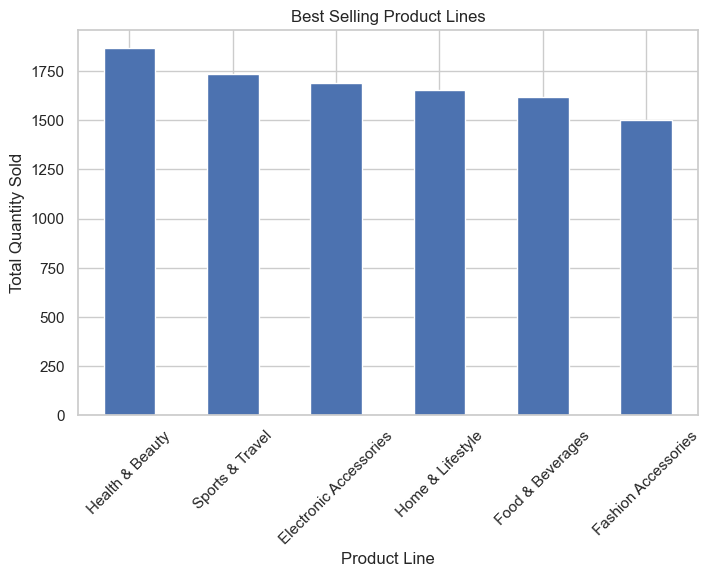

In [18]:
plt.figure(figsize=(8,5))

best_products.plot(kind="bar")

plt.title("Best Selling Product Lines")
plt.xlabel("Product Line")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45)
plt.savefig("C:/data-analysis-portfolio/visualizations/BestSellingproduct.png")

plt.show()

In [16]:
sales_city = df.groupby("City")["Total"].sum().sort_values(ascending=False)

print("\nSales by City")
print(sales_city)


Sales by City
City
Yangon       177069.05
Naypyitaw    176607.69
Mandalay     165603.95
Name: Total, dtype: float64


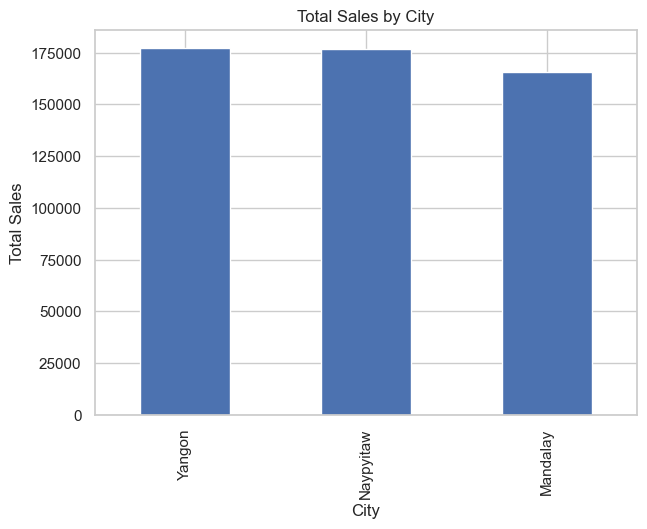

In [20]:
plt.figure(figsize=(7,5))

sales_city.plot(kind="bar")

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.savefig("C:/data-analysis-portfolio/visualizations/Total_Sales_by_city.png")

plt.show()

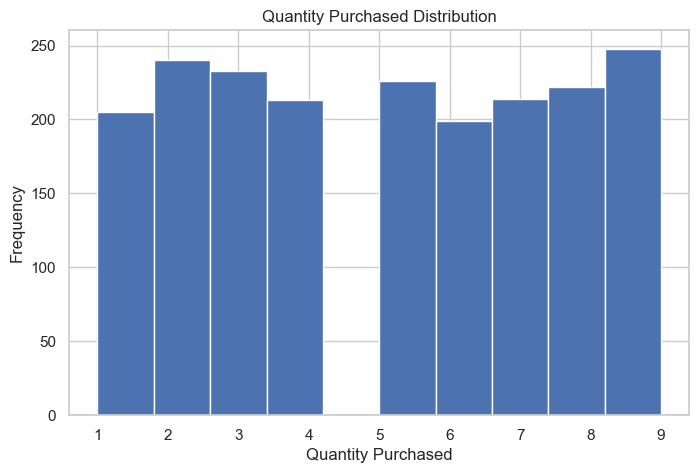

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["Quantity"], bins=10)

plt.title("Quantity Purchased Distribution")
plt.xlabel("Quantity Purchased")
plt.ylabel("Frequency")
plt.savefig("C:/data-analysis-portfolio/visualizations/Quantity_purchased_distribution.png")

plt.show()

In [23]:
payment_method = df["Payment"].value_counts()

print("\nPayment Methods")
print(payment_method)


Payment Methods
Payment
Ewallet        720
Cash           658
Credit card    622
Name: count, dtype: int64


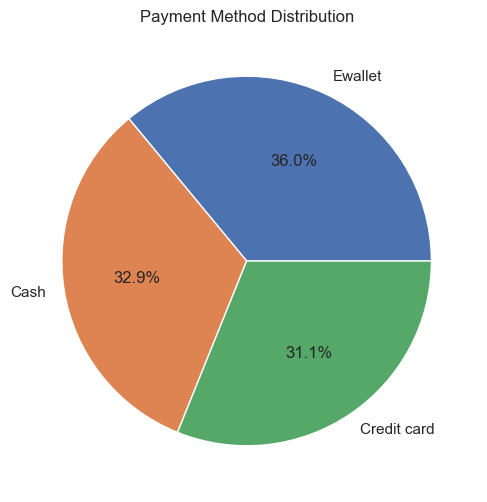

In [24]:
plt.figure(figsize=(6,6))

payment_method.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")

plt.ylabel("")
plt.savefig("C:/data-analysis-portfolio/visualizations/Payment Method Distribution.png")


plt.show()

In [26]:
daily_sales = df.groupby("Date")["Total"].sum()

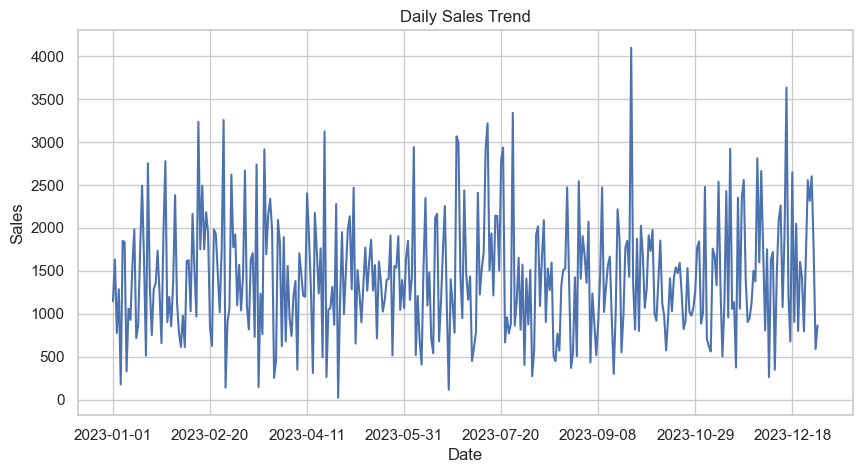

In [27]:
plt.figure(figsize=(10,5))

daily_sales.plot()

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.savefig("C:/data-analysis-portfolio/visualizations/Daily Sales Trend.png")

plt.show()

In [29]:
gender_counts = df["Gender"].value_counts()

print(gender_counts)

Gender
Female    1019
Male       981
Name: count, dtype: int64


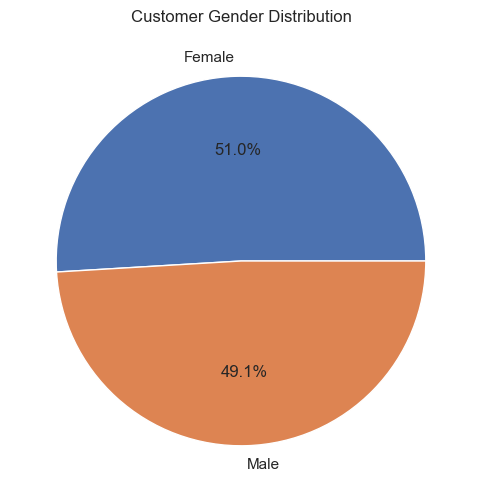

In [30]:
plt.figure(figsize=(6,6))

gender_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Gender Distribution")

plt.ylabel("")
plt.savefig("C:/data-analysis-portfolio/visualizations/Customer Gender Distribution.png")


plt.show()

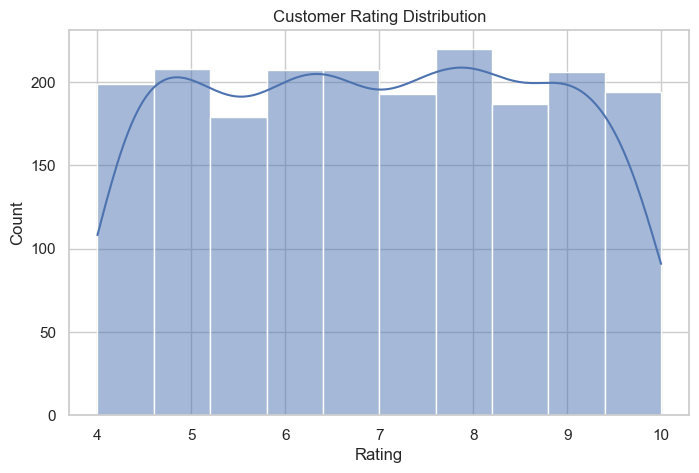

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df["Rating"], bins=10, kde=True)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.savefig("C:/data-analysis-portfolio/visualizations/Customer Rating Distribution.png")


plt.show()

In [32]:
correlation = df[["Unit_Price","Quantity","Tax","Total","Rating"]].corr()

print(correlation)

            Unit_Price  Quantity       Tax     Total    Rating
Unit_Price    1.000000  0.021547 -0.006407  0.004670 -0.013828
Quantity      0.021547  1.000000 -0.021480 -0.012459 -0.015680
Tax          -0.006407 -0.021480  1.000000 -0.004217 -0.016355
Total         0.004670 -0.012459 -0.004217  1.000000 -0.009223
Rating       -0.013828 -0.015680 -0.016355 -0.009223  1.000000


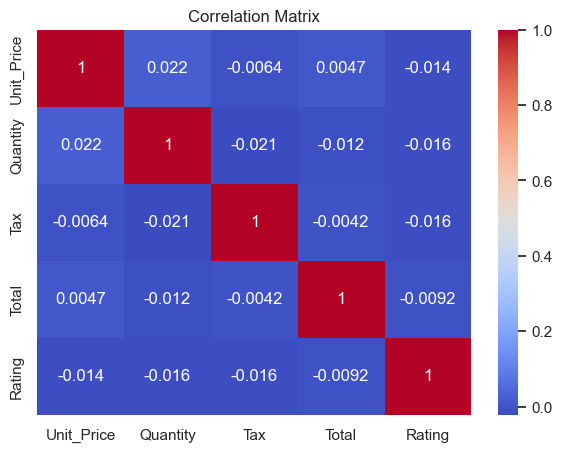

In [33]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.savefig("C:/data-analysis-portfolio/visualizations/Correlation Matrix.png")

plt.show()

In [35]:
top_rated_products = df.groupby("Product_Line")["Rating"].mean().sort_values(ascending=False)

print(top_rated_products)

Product_Line
Food & Beverages          7.053526
Health & Beauty           6.991185
Home & Lifestyle          6.972836
Fashion Accessories       6.942715
Sports & Travel           6.927066
Electronic Accessories    6.862611
Name: Rating, dtype: float64


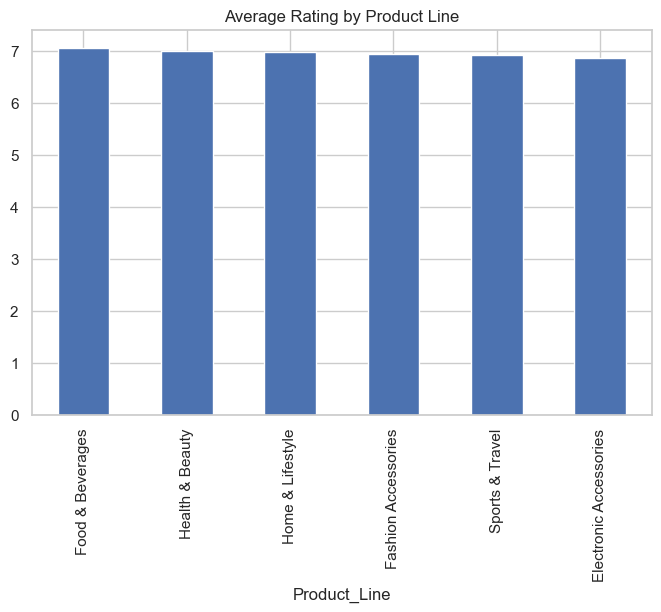

In [36]:
plt.figure(figsize=(8,5))

top_rated_products.plot(kind="bar")

plt.title("Average Rating by Product Line")
plt.savefig("C:/data-analysis-portfolio/visualizations/Average Rating by Product Line.png")

plt.show()